<a href="https://colab.research.google.com/github/teemus28/Machine-Learning/blob/main/FE_Binning_Binarization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/tested.csv",usecols=['Age','Fare','Survived'])

In [ ]:
df

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875
...,...,...,...
413,0,NaN,8.0500
414,1,39.0,108.9000
415,0,38.5,7.2500
416,0,NaN,8.0500


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  418 non-null    int64  
 1   Age       332 non-null    float64
 2   Fare      417 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 9.9 KB


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 331 entries, 0 to 415
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  331 non-null    int64  
 1   Age       331 non-null    float64
 2   Fare      331 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 10.3 KB


In [ ]:
x = df.iloc[:,1:3]
x

,Age,Fare
0,34.5,7.8292
1,47.0,7.0000
2,62.0,9.6875
3,27.0,8.6625
4,22.0,12.2875
...,...,...
409,3.0,13.7750
411,37.0,90.0000
412,28.0,7.7750
414,39.0,108.9000


In [ ]:
y = df.iloc[:,0]
y = pd.DataFrame(y)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [ ]:
x_train.shape

(264, 2)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [ ]:
y_pre = lr.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
#r2_score(y_test,y_pre)
accuracy_score(y_test,y_pre)

0.6716417910447762

In [ ]:
# import pandas as pd
import numpy as np
d = {"Age":[20],"Fare":100}
data = pd.DataFrame(d)

In [ ]:
lr.predict(data)

array([1])

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
np.mean(cross_val_score(lr,x,y,scoring='accuracy'))

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

0.6252826775214835

In [ ]:
from sklearn.preprocessing import KBinsDiscretizer
kbd = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
#kbd_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='uniform')


In [ ]:
from sklearn.compose import ColumnTransformer
txn = ColumnTransformer([("transform",kbd,[0,1])])


In [ ]:
x_train_trf = txn.fit_transform(x_train)
x_test_trf = txn.transform(x_test)

In [ ]:
output = pd.DataFrame({'Age':x_train['Age'],'Age_trf':x_train_trf[:,0],'Fare':x_train['Fare'],'Fare_trf':x_train_trf[:,1]})

In [ ]:
output

,Age,Age_trf,Fare,Fare_trf
179,64.00,14.0,83.1583,13.0
24,48.00,13.0,262.3750,14.0
354,0.17,0.0,20.5750,8.0
197,18.00,2.0,7.7750,2.0
295,26.00,6.0,7.8958,3.0
...,...,...,...,...
356,59.00,14.0,51.4792,11.0
302,43.00,12.0,21.0000,8.0
26,22.00,4.0,61.9792,12.0
412,28.00,7.0,7.7750,2.0


In [ ]:
txn.named_transformers_             #get details of txn

{'transform': KBinsDiscretizer(encode='ordinal', n_bins=15)}

In [ ]:
txn.named_transformers_['transform'].n_bins_              #15 bins created

array([15, 15])

In [ ]:
txn.named_transformers_['transform'].bin_edges_             #interval of bins

array([array([ 0.17, 12.  , 18.  , 21.  , 22.  , 24.  , 25.  , 27.  , 29.  ,
              31.  , 35.  , 39.  , 43.  , 47.  , 55.  , 67.  ])             ,
       array([  0.        ,   7.25      ,   7.775     ,   7.88916   ,
                8.53614   ,  10.5       ,  13.        ,  13.9       ,
               20.575     ,  26.        ,  27.53746667,  36.18333333,
               56.36502   ,  75.24944667, 143.06109333, 512.3292    ])],
      dtype=object)

In [ ]:
output

,Age,Age_trf,Fare,Fare_trf
179,64.00,14.0,83.1583,13.0
24,48.00,13.0,262.3750,14.0
354,0.17,0.0,20.5750,8.0
197,18.00,2.0,7.7750,2.0
295,26.00,6.0,7.8958,3.0
...,...,...,...,...
356,59.00,14.0,51.4792,11.0
302,43.00,12.0,21.0000,8.0
26,22.00,4.0,61.9792,12.0
412,28.00,7.0,7.7750,2.0


In [ ]:
#pd.cut example

data = [1, 7, 5, 4, 6, 8, 3, 2, 9, 10]
bins = [0, 3, 6, 10]
categories = pd.cut(data, bins)   #[(0, 3] < (3, 6] < (6, 10]]  , devide into bins
print(categories)


[(0, 3], (6, 10], (3, 6], (3, 6], (3, 6], (6, 10], (0, 3], (0, 3], (6, 10], (6, 10]]
Categories (3, interval[int64, right]): [(0, 3] < (3, 6] < (6, 10]]


In [ ]:
output['Age_labels']= pd.cut(x_train['Age'],bins = txn.named_transformers_['transform'].bin_edges_[0].tolist())
output['Fare_labels'] = pd.cut(x_train['Fare'],bins = txn.named_transformers_['transform'].bin_edges_[1].tolist())

In [ ]:
output

,Age,Age_trf,Fare,Fare_trf,Age_labels,Fare_labels
179,64.00,14.0,83.1583,13.0,"(55.0, 67.0]","(75.249, 143.061]"
24,48.00,13.0,262.3750,14.0,"(47.0, 55.0]","(143.061, 512.329]"
354,0.17,0.0,20.5750,8.0,NaN,"(13.9, 20.575]"
197,18.00,2.0,7.7750,2.0,"(12.0, 18.0]","(7.25, 7.775]"
295,26.00,6.0,7.8958,3.0,"(25.0, 27.0]","(7.889, 8.536]"
...,...,...,...,...,...,...
356,59.00,14.0,51.4792,11.0,"(55.0, 67.0]","(36.183, 56.365]"
302,43.00,12.0,21.0000,8.0,"(39.0, 43.0]","(20.575, 26.0]"
26,22.00,4.0,61.9792,12.0,"(21.0, 22.0]","(56.365, 75.249]"
412,28.00,7.0,7.7750,2.0,"(27.0, 29.0]","(7.25, 7.775]"


In [ ]:
x_train_trf

array([[14., 13.],
       [13., 14.],
       [ 0.,  8.],
       [ 2.,  2.],
       [ 6.,  3.],
       [10.,  2.],
       [ 0., 10.],
       [ 1., 11.],
       [13., 11.],
       [ 8.,  2.],
       [ 6.,  5.],
       [ 1., 12.],
       [ 1.,  1.],
       [ 9.,  3.],
       [10., 12.],
       [14.,  9.],
       [10.,  1.],
       [13., 13.],
       [ 9.,  1.],
       [ 9., 10.],
       [ 2.,  1.],
       [ 2., 12.],
       [ 5.,  2.],
       [ 8.,  6.],
       [ 9.,  8.],
       [14.,  9.],
       [ 4.,  2.],
       [ 7.,  0.],
       [10.,  0.],
       [ 0.,  4.],
       [ 8., 14.],
       [10., 12.],
       [ 1.,  7.],
       [14.,  6.],
       [ 1.,  7.],
       [13., 12.],
       [10.,  4.],
       [ 3.,  3.],
       [14., 14.],
       [ 6.,  0.],
       [ 3.,  2.],
       [ 3.,  5.],
       [ 4.,  4.],
       [ 4.,  5.],
       [11.,  2.],
       [ 8.,  8.],
       [ 2.,  8.],
       [ 7.,  5.],
       [ 3.,  2.],
       [11.,  7.],
       [ 7.,  4.],
       [10.,  7.],
       [ 6.,

In [ ]:
lr_2 = LogisticRegression()

In [ ]:
lr_2.fit(x_train_trf,y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [ ]:
y_pre_2 = lr_2.predict(x_test_trf)

In [ ]:
accuracy_score(y_test,y_pre_2)   #0.4925373134328358 previous

0.6567164179104478

In [ ]:
np.mean(cross_val_score(lr_2,x_train_trf,y_train))       #0.6252826775214835

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

0.6249637155297532

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def discritize(bins,strategy):
  kbd = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
  #x = kbd.fit_transform()
  # lg = LogisticRegression()
  # lr.fit(X)
  trf = ColumnTransformer([("discritize",kbd,[0,1])])
  x_trf = trf.fit_transform(x)
  # lg = LogisticRegression()
  # lg.fit(x,y)
  # y_pre = lg.predict()
  # accuracy_score()
  print(np.mean(cross_val_score(LogisticRegression(),x,y)))

  plt.figure(figsize=(12,8))

  plt.subplot(2,2,1)
  plt.hist(x['Age'])

  plt.subplot(2,2,2)
  plt.hist(x_trf[:,0])

  plt.subplot(2,2,3)
  plt.hist(x['Fare'])

  plt.subplot(2,2,4)
  plt.hist(x_trf[:,1])



/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

0.6252826775214835


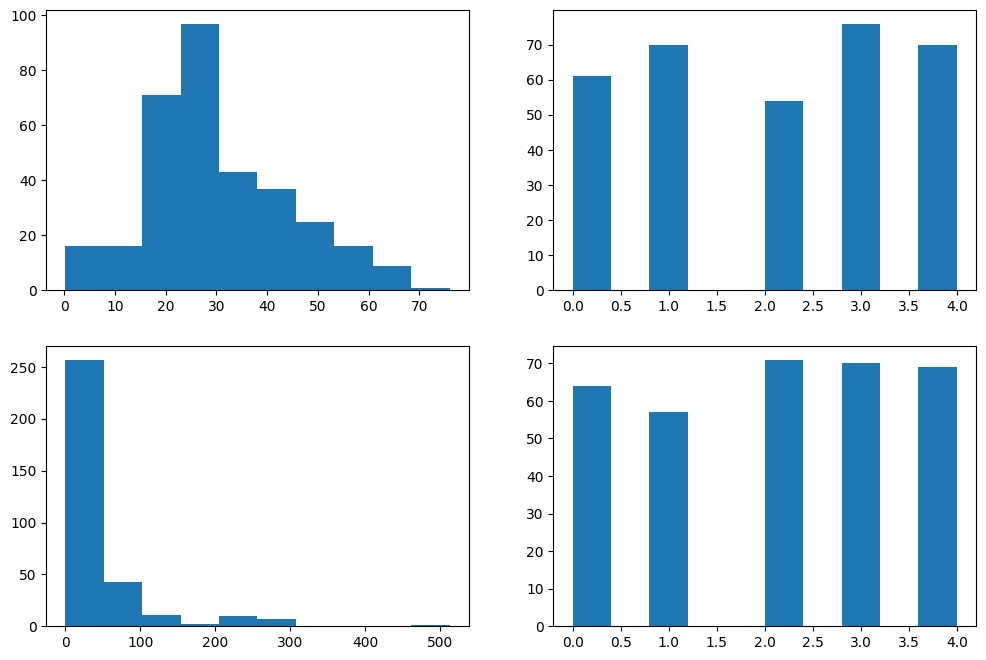

In [ ]:
discritize(5,'quantile')

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

0.6252826775214835


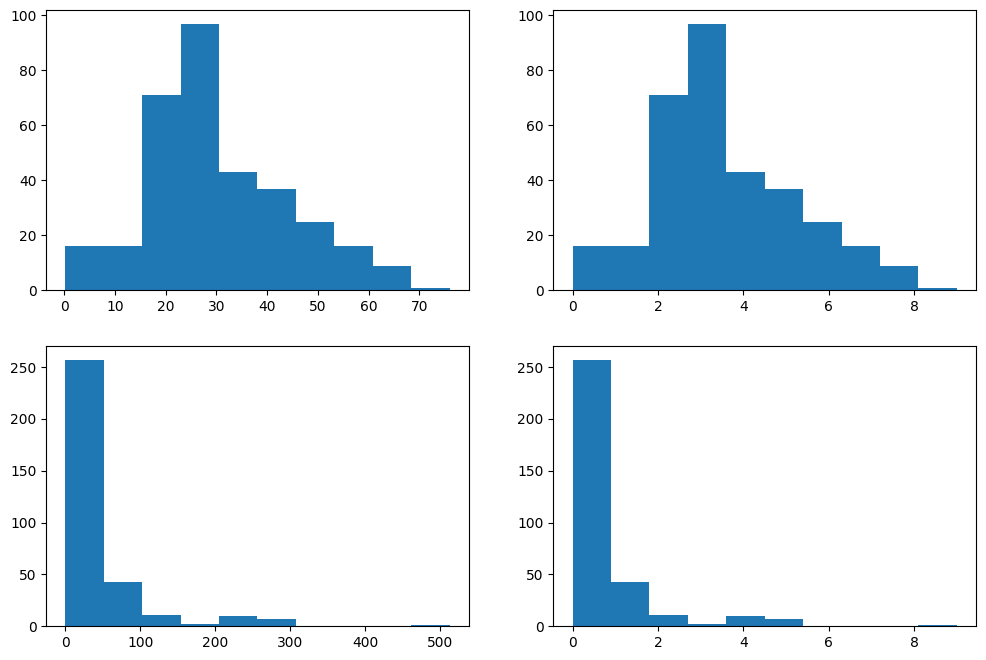

In [ ]:
discritize(10,'uniform')

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

0.6252826775214835


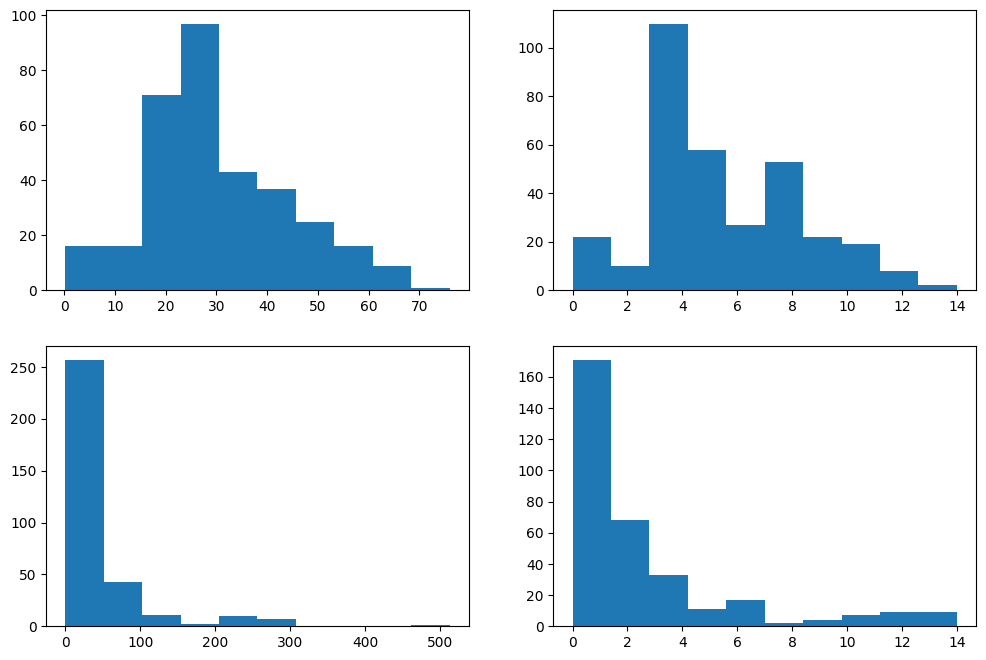

In [ ]:
discritize(15,'kmeans')

# Binarization


In [ ]:
df_2 = pd.read_csv("/content/tested.csv",usecols = ['Survived','Age','SibSp','Parch','Fare'])

In [ ]:
df_2

,Survived,Age,SibSp,Parch,Fare
0,0,34.5,0,0,7.8292
1,1,47.0,1,0,7.0000
2,0,62.0,0,0,9.6875
3,0,27.0,0,0,8.6625
4,1,22.0,1,1,12.2875
...,...,...,...,...,...
413,0,NaN,0,0,8.0500
414,1,39.0,0,0,108.9000
415,0,38.5,0,0,7.2500
416,0,NaN,0,0,8.0500


In [ ]:
#  siblings + parent-child = family
df_2['Family'] = df_2['SibSp']+df_2['Parch']

In [ ]:
df_2.drop(['SibSp','Parch'],axis=1,inplace=True)

In [ ]:
df_2

,Survived,Age,Fare,Family
0,0,34.5,7.8292,0
1,1,47.0,7.0000,1
2,0,62.0,9.6875,0
3,0,27.0,8.6625,0
4,1,22.0,12.2875,2
...,...,...,...,...
413,0,NaN,8.0500,0
414,1,39.0,108.9000,0
415,0,38.5,7.2500,0
416,0,NaN,8.0500,0


In [ ]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  418 non-null    int64  
 1   Age       332 non-null    float64
 2   Fare      417 non-null    float64
 3   Family    418 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 13.2 KB


In [ ]:
df_2.dropna(inplace=True)

In [ ]:
X = df_2.iloc[:,1:]
Y = df_2.iloc[:,0]

In [ ]:
X.head()

,Age,Fare,Family
0,34.5,7.8292,0
1,47.0,7.0000,1
2,62.0,9.6875,0
3,27.0,8.6625,0
4,22.0,12.2875,2


In [ ]:
Y

0      0
1      1
2      0
3      0
4      1
      ..
409    1
411    1
412    1
414    1
415    0
Name: Survived, Length: 331, dtype: int64

In [ ]:
#Before Binarization

from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)
lg = LogisticRegression()
lg.fit(X_train,Y_train)
Y_predict = lg.predict(X_test)
accuracy_score(Y_test,Y_predict)

0.5522388059701493

In [ ]:
X_train

,Age,Fare,Family
381,26.0,7.8792,0
236,64.0,75.2500,1
46,45.0,29.7000,0
50,24.0,60.0000,1
77,55.0,25.7000,2
...,...,...,...
338,25.0,31.5000,0
284,2.0,20.2125,2
82,49.0,26.0000,0
348,24.0,13.5000,0


In [ ]:
df_2
#transforming family ,  0 - when travelling alone , 1 - when travelling with family

,Survived,Age,Fare,Family
0,0,34.5,7.8292,0
1,1,47.0,7.0000,1
2,0,62.0,9.6875,0
3,0,27.0,8.6625,0
4,1,22.0,12.2875,2
...,...,...,...,...
409,1,3.0,13.7750,2
411,1,37.0,90.0000,1
412,1,28.0,7.7750,0
414,1,39.0,108.9000,0


In [ ]:
from sklearn.preprocessing import Binarizer



In [ ]:
bn = Binarizer(copy=False)   # #threshold=0 , bydefault

In [ ]:
X_train['Family'] = bn.fit_transform(X_train[['Family']])
X_test['Family'] = bn.transform(X_test[['Family']])
#X_train_trf

In [ ]:
X_train

,Age,Fare,Family
381,26.0,7.8792,0
236,64.0,75.2500,1
46,45.0,29.7000,0
50,24.0,60.0000,1
77,55.0,25.7000,1
...,...,...,...
338,25.0,31.5000,0
284,2.0,20.2125,1
82,49.0,26.0000,0
348,24.0,13.5000,0


In [ ]:
lg

LogisticRegression()

In [ ]:
lg.fit(X_train,Y_train)

LogisticRegression()

In [ ]:
pre = lg.predict(X_test)

In [ ]:
#from sklearn.metrics import acc

In [ ]:
accuracy_score(Y_test,pre)       #0.5522388059701493

0.5373134328358209